# Point Cloud Transformers Analysis

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import open3d as o3d
import trimesh
import matplotlib.pyplot as plt
import os

from mpl_toolkits.mplot3d import Axes3D  # noqa
from pathlib import Path
from visuals import visualize_samples

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Comparative Visual for Report

Just a quick visual to show the different datasets.

In [60]:
# Load all PAPNet and PCT data
pap_partial = np.load(os.path.join('..', 'datasets', 'partialmodelnet40', 'train_points.npy'))
pap_full = np.load(os.path.join('..', 'datasets', 'fullmodelnet40', 'train_points.npy'))
pap_partial_10 = np.load(os.path.join('..', 'datasets', 'pm40_partiality_level', 'train_points_10.npy'))
pap_partial_30 = np.load(os.path.join('..', 'datasets', 'pm40_partiality_level', 'train_points_30.npy'))
pap_partial_40 = np.load(os.path.join('..', 'datasets', 'pm40_partiality_level', 'train_points_40.npy'))

# Loads PCT style data, only the airplane folder
folder = Path(os.path.join('..', 'datasets', 'modelnet40_normal_resampled', 'airplane'))
files = sorted(folder.glob('*.txt'))
arrays = []
for f in files:
    arr = np.loadtxt(f, delimiter=',')
    arrays.append(arr)
pct_airplanes = np.stack(arrays, axis=0)

In [ ]:
# Gather samples for combined plot
viz_points = [
    pap_partial[4],
    pap_full[7],
    pct_airplanes[0],
    pap_partial_10[4],
    pap_partial_30[4],
    pap_partial_40[4]
]

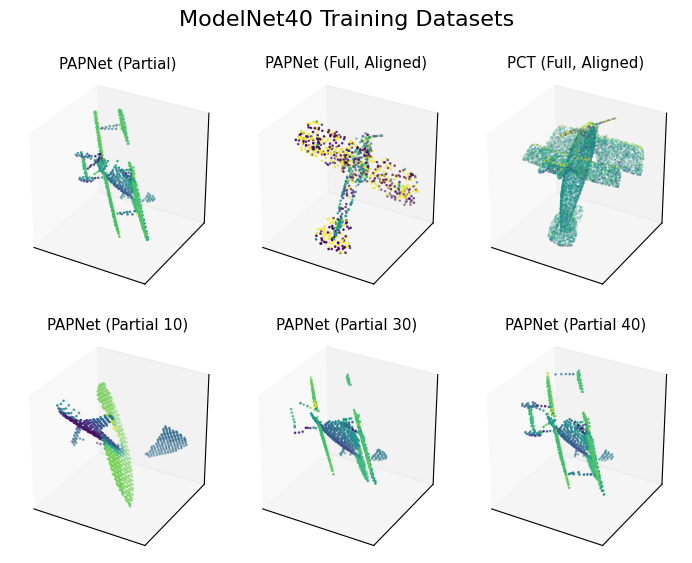

In [ ]:
visualize_samples(
    data=viz_points,
    title='ModelNet40 Training Datasets',
    figsize=(7, 6),
    labels=[
        'PAPNet (Partial)', 'PAPNet (Full, Aligned)', 'PCT (Full, Aligned)',
        'PAPNet (Partial 10)', 'PAPNet (Partial 30)', 'PAPNet (Partial 40)'
    ],
    point_size=[0.8, 0.8, 0.05, 0.8, 0.8, 0.8],
    font_size=9
)

## Performance Analytics

In [73]:
pct_results = pd.read_csv('../runs/pct_results.csv', sep=';')
pct_results.head(5)

,y_true,pct_pct,pct_pap,pap_pap,pap_pct
0,0,0,19,0,0
1,0,0,9,0,0
2,0,0,9,0,33
3,0,0,27,0,0
4,0,0,17,0,0


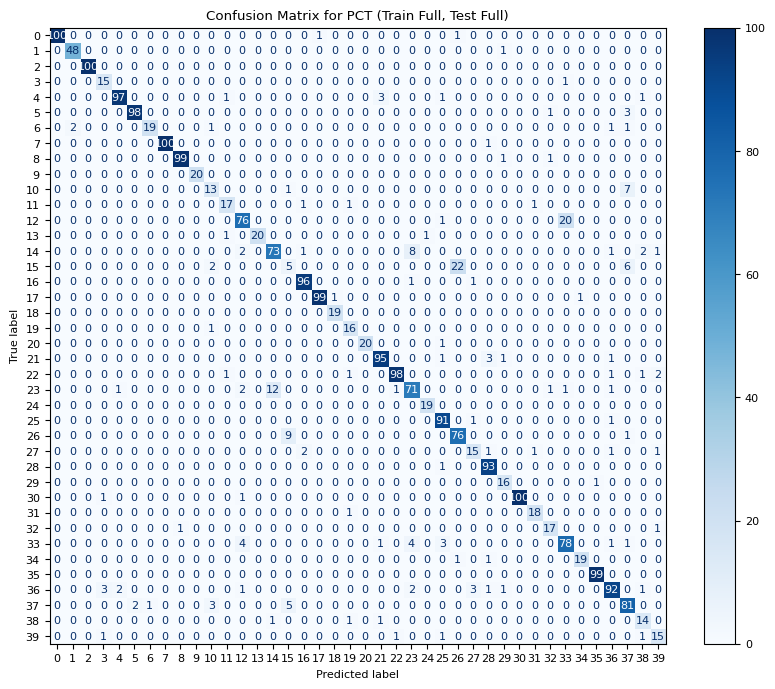

In [76]:
fig, ax = plt.subplots(figsize=(10, 8))
plt.rcParams.update({'font.size': 8})

cm = confusion_matrix(pct_results.pct_pct, pct_results.y_true)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix for PCT (Train Full, Test Full)")
plt.show()

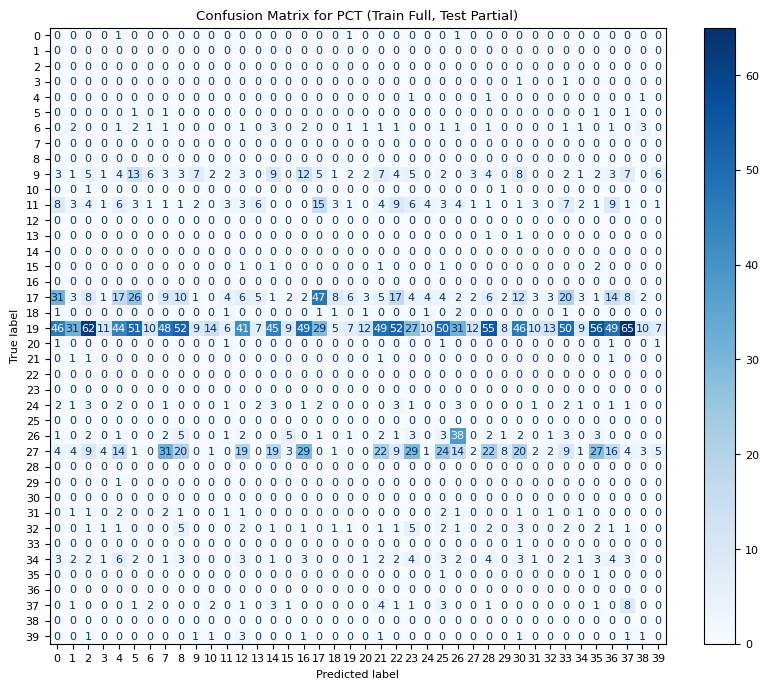

In [78]:
fig, ax = plt.subplots(figsize=(10, 8))
plt.rcParams.update({'font.size': 8})

cm = confusion_matrix(pct_results.pct_pap, pct_results.y_true)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix for PCT (Train Full, Test Partial)")
plt.show()

In [ ]:
# Let's look at category 17, 19, and 27 to see what they have in common to cause the model to collapse
data_names = [line.rstrip() for line in open(os.path.join('..', 'datasets', 'modelnet40_normal_resampled', 'modelnet40_train.txt'))]